In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error

DATA = Path.cwd()
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10, 'figure.dpi': 120})
pd.set_option('display.width', 150)
pd.set_option('display.max_columns', 10)

## 1. Загрузка и подготовка данных
Исследуем мощность офисного здания из DataSet3_1.csv. Измерения идут каждые
15 минут. Берём первые 480 последовательных значений: 384 для обучения
и 96 для теста. Тестовый горизонт составляет сутки. Данные не перемешиваем.
Температуру переводим в °C, время — в часы от начала фрагмента.
DataSet3_2.csv в этой работе не нужен: все модели строятся на одном наборе.

In [2]:
data = pd.read_csv(DATA / 'DataSet3_1.csv')
data['Timestamp'] = pd.to_datetime(data['Timestamp'], format='%m/%d/%Y %H:%M')
for col in ['Power (kW)', 'OAT (F)']:
    data[col] = pd.to_numeric(data[col], errors='raise')
data = data.sort_values('Timestamp').reset_index(drop=True)
data['Temperature (C)'] = (data['OAT (F)'] - 32) * 5 / 9

N = 480
sample = data.iloc[:N].copy().reset_index(drop=True)
assert len(sample) == N and N >= 100
assert not sample.isna().any().any()
assert not sample['Timestamp'].duplicated().any()
assert sample['Timestamp'].diff().dropna().eq(pd.Timedelta(minutes=15)).all()
sample['Time (h)'] = (sample['Timestamp'] - sample['Timestamp'].iloc[0]).dt.total_seconds() / 3600
n_train = int(N * 0.8)
train = sample.iloc[:n_train].copy()
test = sample.iloc[n_train:].copy()
y_train = train['Power (kW)'].to_numpy()
y_test = test['Power (kW)'].to_numpy()
horizon = len(test)
assert train['Timestamp'].max() < test['Timestamp'].min()
print(f'Всего: {N}; обучение: {len(train)}; тест: {len(test)}.')
print(f'Обучение: {train.Timestamp.iloc[0]} — {train.Timestamp.iloc[-1]}')
print(f'Тест: {test.Timestamp.iloc[0]} — {test.Timestamp.iloc[-1]}')
print(sample[['Power (kW)', 'Temperature (C)']].describe().round(3))

Всего: 480; обучение: 384; тест: 96.
Обучение: 2010-01-01 01:15:00 — 2010-01-05 01:00:00
Тест: 2010-01-05 01:15:00 — 2010-01-06 01:00:00
       Power (kW)  Temperature (C)
count     480.000          480.000
mean      238.104           10.125
std        60.724            2.933
min       143.300            3.889
25%       165.075            8.333
50%       266.200           10.000
75%       285.225           12.361
max       349.600           16.667


## 2. ARIMA и скользящее среднее
ARIMA(4, 1, 1) использует четыре лага разностей, одно дифференцирование
и компоненту ошибки первого порядка. Порядок выбран заранее, без подбора по тесту.
Это простая несезонная модель: суточный период в неё явно не включён.
Скользящее среднее использует 8 последних значений, то есть два часа наблюдений.
При прогнозе на несколько шагов новые прогнозы добавляются в историю вместо
ещё неизвестных фактических значений. Тестовые измерения в прогноз не подставляем.
Скользящее среднее здесь — среднее последних наблюдений, а не MA-компонента ARIMA.

In [3]:
ORDER = (4, 1, 1)
WINDOW = 8

def forecast_arima(values, steps):
    model = ARIMA(np.asarray(values, dtype=float), order=ORDER).fit()
    if not model.mle_retvals.get('converged', True):
        raise RuntimeError('ARIMA не сошлась: требуется пересмотреть параметры.')
    return model, np.asarray(model.forecast(steps=steps))

def forecast_mean(values, steps, window=WINDOW):
    history = list(np.asarray(values, dtype=float))
    forecast = []
    for _ in range(steps):
        value = float(np.mean(history[-window:]))
        forecast.append(value)
        history.append(value)
    return np.asarray(forecast)

arima_model, arima_pred = forecast_arima(y_train, horizon)
mean_pred = forecast_mean(y_train, horizon)
predictions = {'ARIMA(4,1,1)': arima_pred, 'Скользящее среднее (8)': mean_pred}
arima_fit = np.asarray(arima_model.fittedvalues).copy()
arima_fit[:max(1, arima_model.loglikelihood_burn)] = np.nan
train_fits = {'ARIMA(4,1,1)': arima_fit,
              'Скользящее среднее (8)': pd.Series(y_train).shift(1).rolling(WINDOW).mean().to_numpy()}
print('Прогноз ARIMA, первые 5 значений:', arima_pred[:5].round(3))
print('Прогноз среднего, первые 5 значений:', mean_pred[:5].round(3))

Прогноз ARIMA, первые 5 значений: [162.86  165.828 166.312 166.12  166.544]
Прогноз среднего, первые 5 значений: [169.3   166.475 162.509 161.536 161.415]


## 3. Регрессия с одним признаком
Предсказываем мощность по времени: x — часы от начала ряда, y — мощность в кВт.
МНК имеет вид y = c0 + c1*x. Коэффициенты находим через np.linalg.lstsq:
этот способ решает задачу наименьших квадратов без явного обращения матрицы.
Для SVR используем линейное ядро, C=10 и epsilon=5 кВт. Признаки стандартизируем
только по обучающей выборке. Настройки фиксированы до оценки теста.

In [4]:
def fit_ols(x_train, target, x_future):
    a_train = np.column_stack([np.ones(len(x_train)), x_train])
    a_future = np.column_stack([np.ones(len(x_future)), x_future])
    coefficients = np.linalg.lstsq(a_train, target, rcond=None)[0]
    return coefficients, a_train @ coefficients, a_future @ coefficients

def fit_svr(x_train, target, x_future):
    model = make_pipeline(StandardScaler(), SVR(kernel='linear', C=10.0, epsilon=5.0))
    model.fit(x_train, target)
    return model, model.predict(x_train), model.predict(x_future)

x1_train = train[['Time (h)']].to_numpy()
x1_test = test[['Time (h)']].to_numpy()
coef1, train_fits['МНК: время'], predictions['МНК: время'] = fit_ols(x1_train, y_train, x1_test)
svr1, train_fits['SVR: время'], predictions['SVR: время'] = fit_svr(x1_train, y_train, x1_test)
print(f'МНК: y = {coef1[0]:.4f} {coef1[1]:+.4f} * время_в_часах')

МНК: y = 227.6555 +0.2199 * время_в_часах


## 4. Регрессия с двумя признаками
Добавляем температуру: y = c0 + c1*x1 + c2*x2, где x1 — время, x2 — температура.
В обучении используем измеренную температуру. На момент прогноза её будущие
значения неизвестны, поэтому отдельно прогнозируем их ARIMA по первым 384 точкам.
Оба двухпризнаковых метода получают один и тот же прогноз температуры.
Так все шесть моделей используют только информацию, доступную до начала теста.
Ошибка двухпризнаковых моделей включает и ошибку прогноза температуры.

In [5]:
temperature_model, temperature_pred = forecast_arima(train['Temperature (C)'].to_numpy(), horizon)
x2_train = train[['Time (h)', 'Temperature (C)']].to_numpy()
x2_test = np.column_stack([test['Time (h)'].to_numpy(), temperature_pred])
coef2, train_fits['МНК: время + температура'], predictions['МНК: время + температура'] = fit_ols(
    x2_train, y_train, x2_test)
svr2, train_fits['SVR: время + температура'], predictions['SVR: время + температура'] = fit_svr(
    x2_train, y_train, x2_test)
print(f'МНК: y = {coef2[0]:.4f} {coef2[1]:+.4f} * время_в_часах '
      f'{coef2[2]:+.4f} * температура_в_C')
print('Прогноз температуры, первые 5 значений:', temperature_pred[:5].round(3))
for name, values in predictions.items():
    assert len(values) == horizon and np.isfinite(values).all(), name

МНК: y = 30.0227 +0.8837 * время_в_часах +16.0022 * температура_в_C
Прогноз температуры, первые 5 значений: [6.667 6.667 6.667 6.667 6.667]


## 5. Графики моделей
На каждом рисунке показаны реальные значения обучающей и тестовой выборок,
значения модели на обучении и прогноз на весь тестовый горизонт.
Вертикальная линия отделяет обучение от теста. Значения ARIMA и скользящего
среднего на обучении — одношаговые оценки с известной предысторией.
У МНК и SVR это подгонка по обучающему набору. Эти линии не являются тестовым прогнозом.

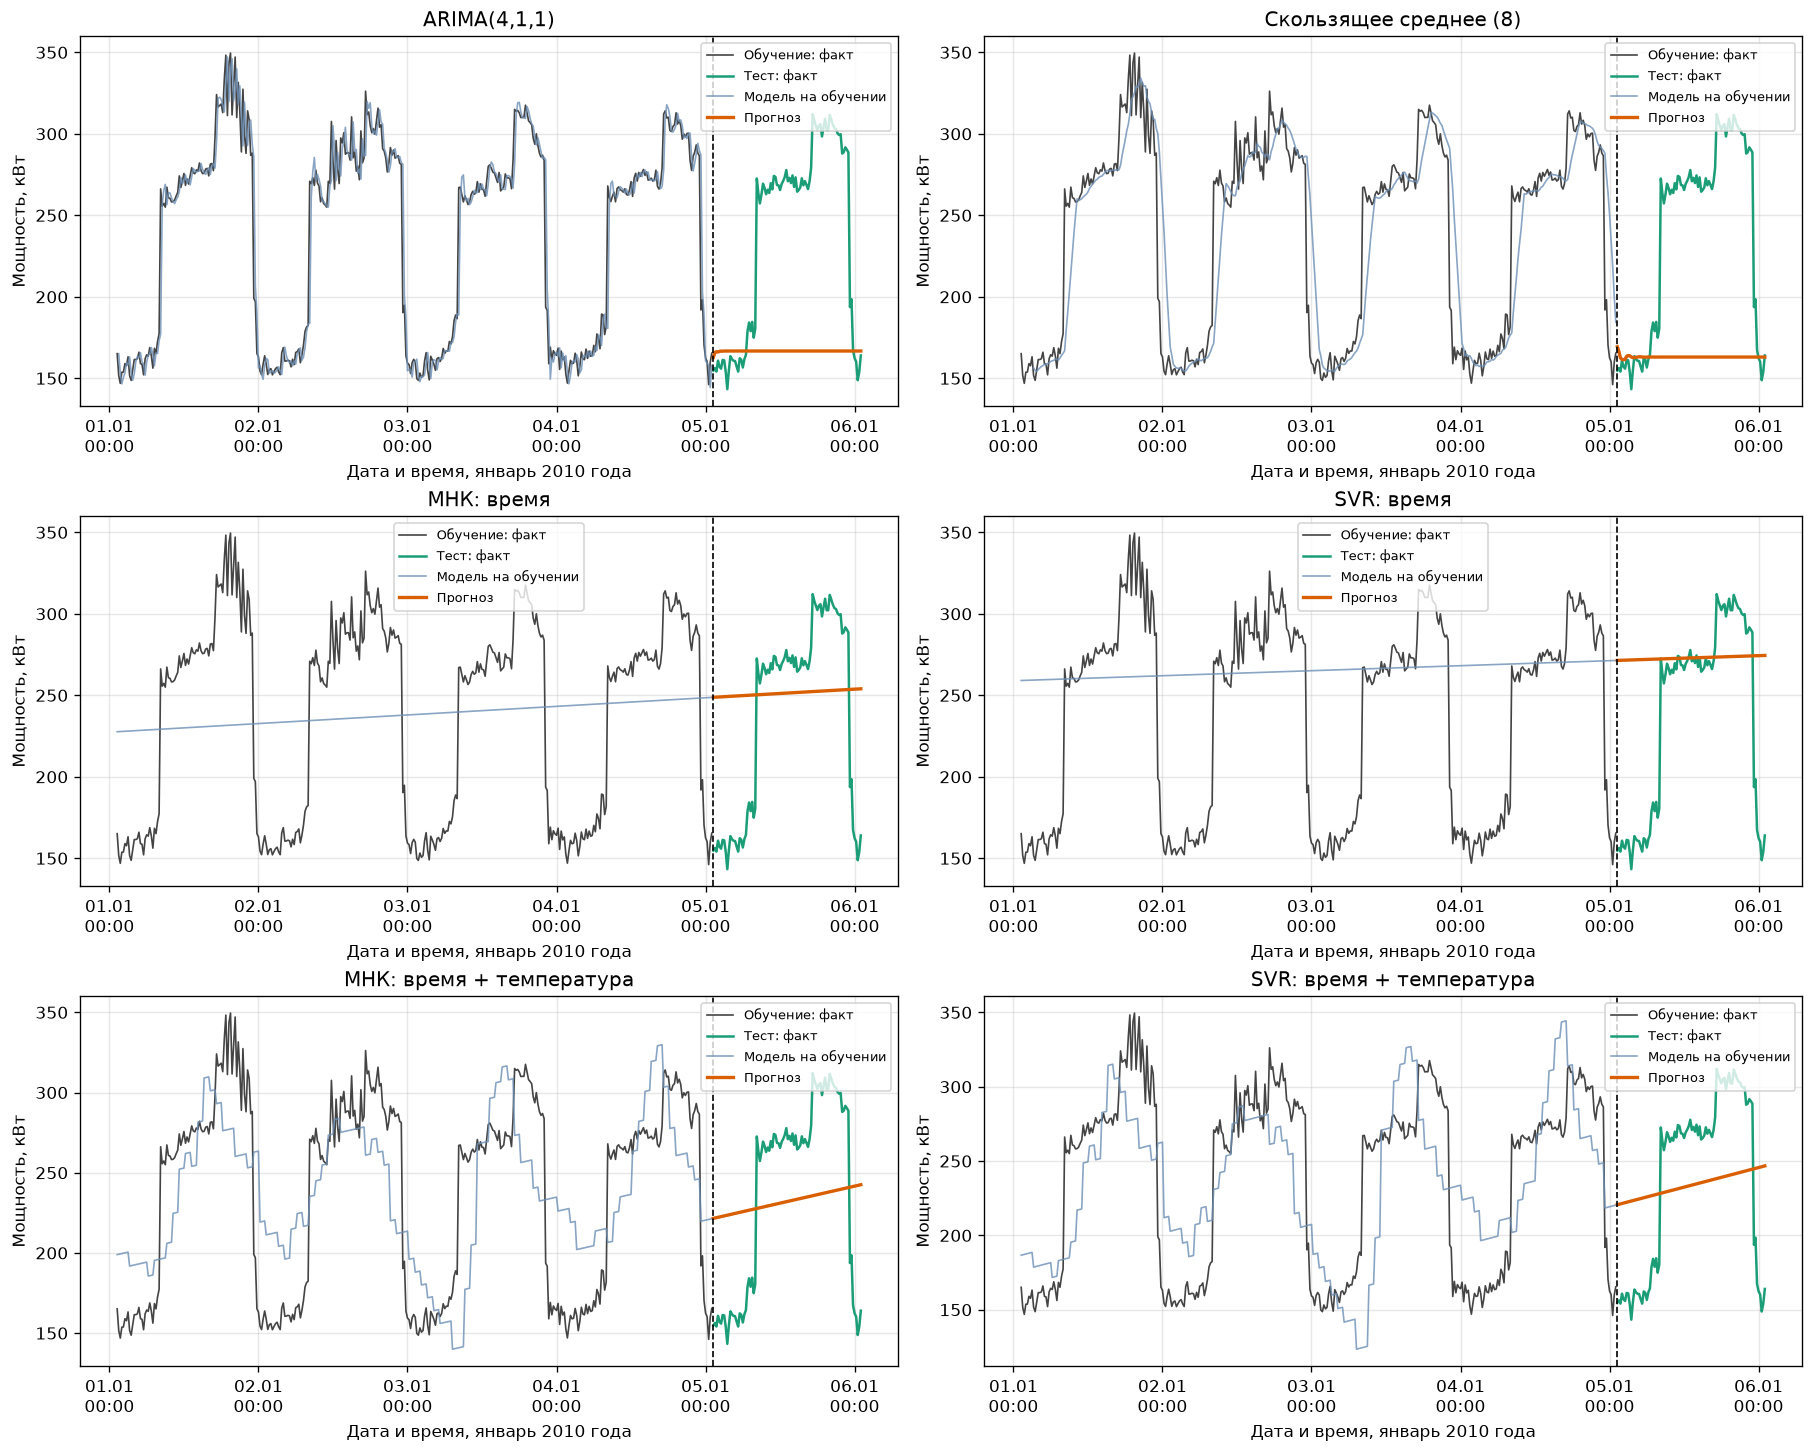

In [6]:
def style_time_axis(ax):
    ax.set_xlabel('Дата и время, январь 2010 года')
    ax.set_ylabel('Мощность, кВт')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m\n%H:%M'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=7))
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

fig, axes = plt.subplots(3, 2, figsize=(15, 12), layout='constrained')
for ax, (name, forecast) in zip(axes.flat, predictions.items()):
    ax.plot(train['Timestamp'], y_train, color='#444444', linewidth=1, label='Обучение: факт')
    ax.plot(test['Timestamp'], y_test, color='#1b9e77', linewidth=1.5, label='Тест: факт')
    ax.plot(train['Timestamp'], train_fits[name], color='#6c8fb5', alpha=0.8,
            linewidth=1, label='Модель на обучении')
    ax.plot(test['Timestamp'], forecast, color='#d95f02', linewidth=2, label='Прогноз')
    ax.axvline(test['Timestamp'].iloc[0], color='black', linestyle='--', linewidth=1)
    ax.set_title(name)
    style_time_axis(ax)
    ax.legend(fontsize=8, loc='best')
plt.show()

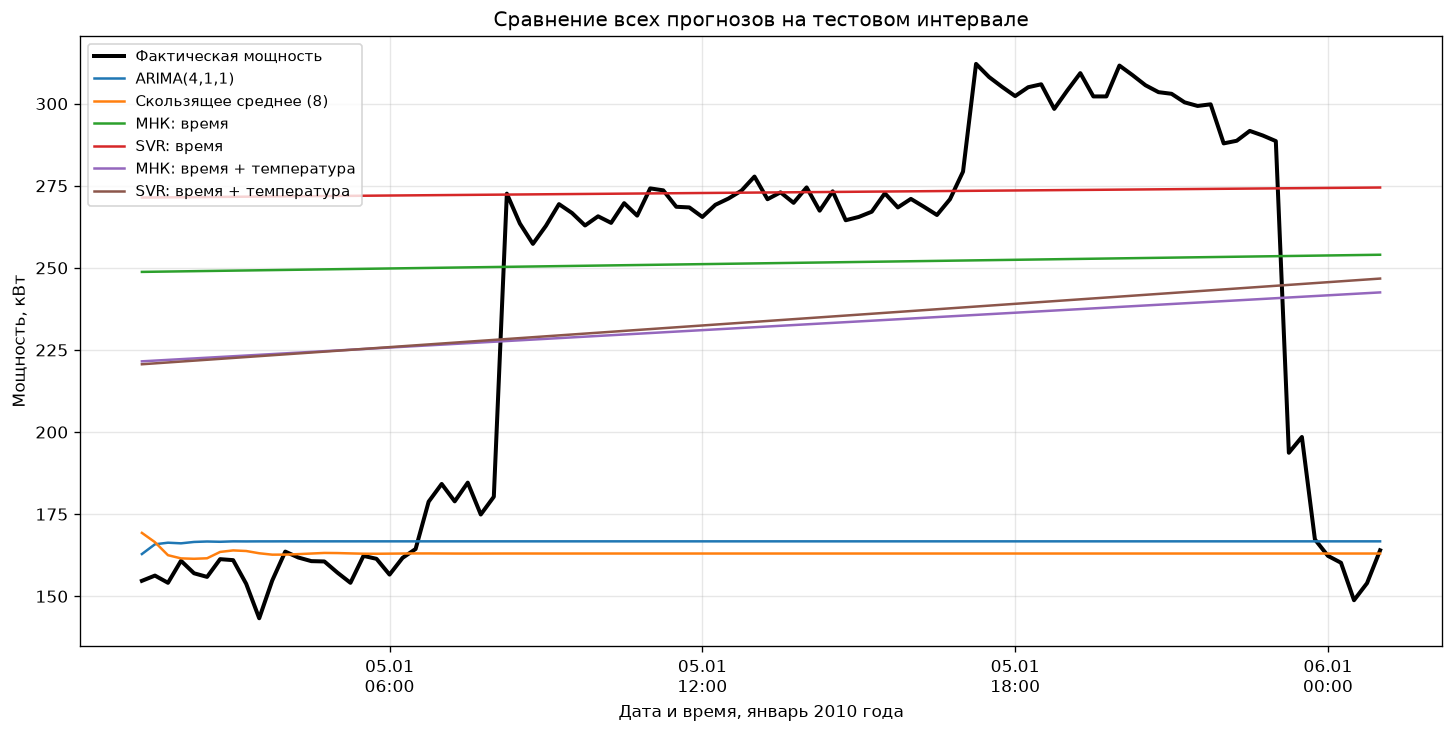

In [7]:
fig, ax = plt.subplots(figsize=(12, 6), layout='constrained')
ax.plot(test['Timestamp'], y_test, color='black', linewidth=2.4, label='Фактическая мощность')
for name, forecast in predictions.items():
    ax.plot(test['Timestamp'], forecast, linewidth=1.5, label=name)
ax.set_title('Сравнение всех прогнозов на тестовом интервале')
style_time_axis(ax)
ax.legend(fontsize=9, loc='best')
plt.show()

## 6. Сравнение точности
Метрики рассчитываем на одних и тех же 96 тестовых измерениях.
MAE — средняя абсолютная ошибка. RMSE — корень из средней квадратичной ошибки:
крупные отклонения влияют на неё сильнее. Обе метрики измеряются в кВт;
чем они меньше, тем точнее прогноз. Тест не использовался при обучении и настройке.

In [8]:
metrics = pd.DataFrame([
    {'Модель': name, 'MAE, кВт': mean_absolute_error(y_test, forecast),
     'RMSE, кВт': np.sqrt(mean_squared_error(y_test, forecast))}
    for name, forecast in predictions.items()
]).set_index('Модель').sort_values('RMSE, кВт')
print(metrics.round(3).to_string())
comparison = pd.DataFrame({'Время': test['Timestamp'].to_numpy(), 'Факт, кВт': y_test, **predictions})
print('\nПервые 10 тестовых прогнозов:')
print(comparison.head(10).round({name: 3 for name in ['Факт, кВт', *predictions]}).to_string(index=False))

                          MAE, кВт  RMSE, кВт
Модель                                       
SVR: время + температура    52.841     55.281
МНК: время + температура    53.927     56.135
МНК: время                  51.164     59.790
SVR: время                  49.272     68.314
ARIMA(4,1,1)                75.881     92.391
Скользящее среднее (8)      77.702     95.290

Первые 10 тестовых прогнозов:
              Время  Факт, кВт  ARIMA(4,1,1)  Скользящее среднее (8)  МНК: время  SVR: время  МНК: время + температура  SVR: время + температура
2010-01-05 01:15:00      154.7       162.860                 169.300     248.770     271.415                   221.538                   220.646
2010-01-05 01:30:00      156.3       165.828                 166.475     248.825     271.447                   221.759                   220.921
2010-01-05 01:45:00      154.1       166.312                 162.509     248.880     271.479                   221.980                   221.195
2010-01-05 02:00:00  

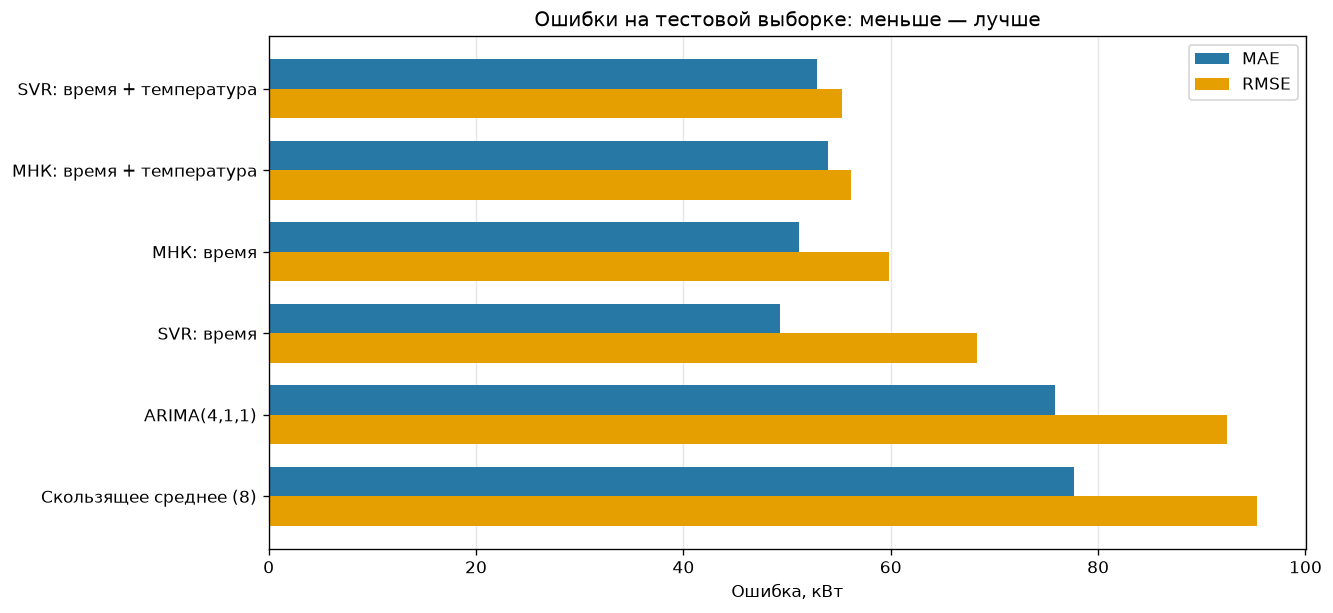

In [9]:
fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
positions = np.arange(len(metrics))
ax.barh(positions - 0.18, metrics['MAE, кВт'], height=0.36, label='MAE', color='#2878a5')
ax.barh(positions + 0.18, metrics['RMSE, кВт'], height=0.36, label='RMSE', color='#e69f00')
ax.set_yticks(positions, metrics.index)
ax.invert_yaxis()
ax.set_xlabel('Ошибка, кВт')
ax.set_title('Ошибки на тестовой выборке: меньше — лучше')
ax.set_axisbelow(True)
ax.grid(axis='x', alpha=0.3)
ax.legend()
plt.show()

In [10]:
best_rmse = metrics['RMSE, кВт'].idxmin()
best_mae = metrics['MAE, кВт'].idxmin()
print(f'Минимальная RMSE: {best_rmse} — {metrics.loc[best_rmse, "RMSE, кВт"]:.3f} кВт.')
print(f'Минимальная MAE: {best_mae} — {metrics.loc[best_mae, "MAE, кВт"]:.3f} кВт.')
print(f'Средняя мощность теста: {y_test.mean():.3f} кВт; '
      f'диапазон: {y_test.min():.1f}–{y_test.max():.1f} кВт.')
for prefix in ['МНК', 'SVR']:
    before = metrics.loc[f'{prefix}: время', 'RMSE, кВт']
    after = metrics.loc[f'{prefix}: время + температура', 'RMSE, кВт']
    print(f'{prefix}: добавление температуры '
          f'{"снизило" if after < before else "увеличило"} RMSE на {abs(after-before):.3f} кВт.')

Минимальная RMSE: SVR: время + температура — 55.281 кВт.
Минимальная MAE: SVR: время — 49.272 кВт.
Средняя мощность теста: 237.778 кВт; диапазон: 143.3–312.1 кВт.
МНК: добавление температуры снизило RMSE на 3.654 кВт.
SVR: добавление температуры снизило RMSE на 13.033 кВт.


## Выводы
На тестовом интервале мощность меняется от 143,3 до 312,1 кВт и сохраняет
выраженный суточный профиль. Простые модели не воспроизводят эти колебания полностью.

ARIMA и скользящее среднее остаются около ночного уровня 160–170 кВт,
поэтому сильно занижают дневную и вечернюю мощность. Их RMSE составляет
92,391 и 95,290 кВт соответственно. Несезонная ARIMA с четырьмя лагами
не описывает явно цикл из 96 измерений, а среднее на длинном горизонте сглаживается.

МНК и линейная SVR по времени описывают общий уровень и наклон, но не суточную
форму ряда. Добавление температуры снизило RMSE: у МНК с 59,790 до 56,135 кВт,
у SVR с 68,314 до 55,281 кВт. При этом MAE выросла у обеих моделей:
улучшение по одной метрике не означает улучшения по всем критериям.
Прогноз температуры оказался почти постоянным, поэтому второй признак также
не позволил восстановить суточный профиль. Его погрешность влияет на прогноз мощности.

Наименьшая RMSE у SVR с двумя признаками — 55,281 кВт, а наименьшая MAE
у SVR только по времени — 49,272 кВт. Вторая модель лучше по средней абсолютной
ошибке, но имеет более крупные отдельные отклонения, сильнее влияющие на RMSE.
Даже минимальная RMSE составляет около 23% средней тестовой мощности (237,778 кВт).
Это лишь сопоставление масштаба ошибки со средним, а не отдельная процентная метрика.
Точность на этом горизонте ограниченная: лучшая из рассмотренных моделей
всё равно заметно ошибается. Результат относится к выбранным пяти суткам и одному
разделению 80/20; переносить этот рейтинг на весь год без новых проверок нельзя.